# Spatial niche identification in the STARmap PLUS mouse brain slice

This notebook applies **IDEA** to identify spatial niches in a **STARmap PLUS mouse brain slice**.

The workflow includes:

1. importing the required packages;
2. specifying the spatial transcriptomics dataset;
3. initializing the IDEA niche identification model;
4. training the model to learn spatially informed representations;
5. predicting and visualizing spatial niches;
6. saving the niche predictions, annotated `AnnData` object, and trained model; and
7. identifying genes associated with the inferred niches using model attribution.


## 1. Import required packages

`scanpy` is used for handling and visualizing spatial transcriptomics data stored as `AnnData` objects, while `init_niche_model` initializes **IDEA-N** for spatial niche identification.


In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import scanpy as sc
from IDEA import init_niche_model

## 2. Specify the spatial transcriptomics dataset

`paths` contains the input `.h5ad` file


In [2]:
path = "/home/ren_jiale/RJL/domain_data/highbrain/highbrain_sagittal1.h5ad"

## 3. Initialize the IDEA model

`init_niche_model` initializes IDEA for spatial niche identification on a single spatial transcriptomics slice.

Key settings used here include:

- `st_ad=path`: input the path of spatial transcriptomics dataset.
- `output_dir="./results/niche_example"`: directory for model outputs.
- `use_condition=False`: disables conditional modeling because only a single slice is analyzed.
- `spatial_key="spatial"`: key containing the spatial coordinates.
- `sliding=True`: uses sliding spatial partitioning.
- `use_hvg=True`, `n_top_hvg=2000`: selects 2,000 highly variable genes for model training.
- `target=4096`, `min_spots=1000`, `max_spots=6000`: control the target, minimum, and maximum sizes of local spatial blocks.
- `knn_k=25`: number of spatial neighbors used for local neighborhood construction.
- `spatial_weight=75.0`: weight of the spatial regularization objective.
- `radius_scale=7.5`: controls the spatial neighborhood radius.
- `hidden_size=512`, `latent_size=128`: dimensions of the hidden and latent representations.
- `dropout=0.0`: dropout rate used during model training.
- `seed=42`: random seed for reproducibility.

The block-wise design restricts neighborhood aggregation to local spatial contexts rather than constructing a global spatial graph over the entire slice.


In [3]:
model = init_niche_model(
    st_ad=path,
    output_dir="./results/niche_example",
    use_condition=False,
    spatial_key= 'spatial',
    sliding=True,
    n_top_hvg = 2000,
    target=4096,
    use_hvg=True,
    min_spots=1000,
    max_spots=6000,
    knn_k=25,
    spatial_weight=75,
    radius_scale=7.5,
    hidden_size=512,
    latent_size=128,
    dropout=0.0,
    seed=42,
    lr_encoder=1e-3,
    lr_decoder=1e-3,
    lr_classifier=1e-2,
)

[IDEA-N] Path-streaming mode enabled: 1 section(s). Only one complete h5ad is kept in RAM at a time.
[IDEA-N] Reading gene metadata for highbrain_sagittal1...
[IDEA-N] Number of common genes: 1022
[IDEA-N] Selecting HVGs for highbrain_sagittal1...
[IDEA-N] highbrain_sagittal1: 1022 HVGs
[IDEA-N] Final HVG union: 1022 genes
[IDEA-N] Preparing highbrain_sagittal1...


## 4. Train the niche identification model

IDEA is trained in two stages.

- **Stage 1** learns a spatially informed latent representation using reconstruction and spatial regularization.
- **Stage 2** trains the niche predictor using clustering-derived pseudo-labels.

Here, Stage 1 is trained for `50` epochs and Stage 2 for `100` epochs. The analysis targets **57 spatial niches**. Leiden clustering is searched over resolutions from `1.0` to `3.0` with a step size of `0.1`, using `25` neighbors to obtain the intermediate niche assignments.


In [4]:
history = model.train_model(
    stage1_epochs=50,
    stage2_epochs=100,
    n_clusters=57,
    leiden_res_range=(1.0, 3.0),
    leiden_res_step=0.1,
    leiden_neighbors=25,
)

[IDEA-N stage2] 100/100: 100%|██████████| 24/24 [00:00<00:00, 36.86it/s, class_loss=0.233]


## 5. Predict and visualize spatial niches

After training, `model.predict()` assigns a spatial niche to each spatial unit and stores the resulting categorical labels under `obs["niche"]`.

The inferred niches are then visualized using the spatial coordinates stored in `obsm["spatial"]`, allowing the spatial organization of the predicted brain regions to be examined directly.


[IDEA-N] embedding: 100%|██████████| 24/24 [00:00<00:00, 30.70it/s]
/home/ren_jiale/miniconda3/envs/eve_rebuild/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


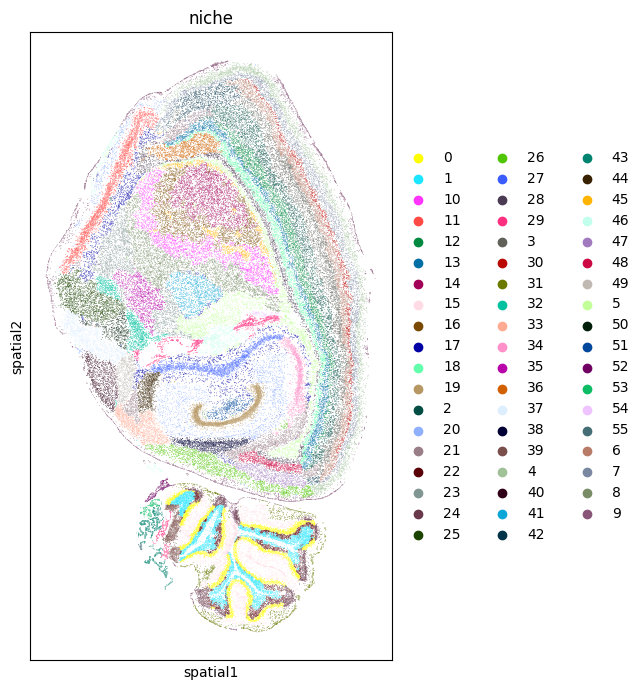

In [5]:
pred = model.predict(obs_key="niche")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, figsize=(7, 7))

sc.pl.embedding(
    model.adatas[0],
    basis = 'spatial',
    color='niche',
    size=1,
    cmap="viridis",
    ax=ax,
    show=False
)

ax.set_aspect("equal")
ax.invert_yaxis()

plt.tight_layout()
 

## 6. Save the niche identification results

The main outputs are saved for downstream analysis and reproducibility:

- `niche_predictions.csv`: predicted niche assignment for each spatial unit.
- `st_with_niche.h5ad`: the annotated spatial `AnnData` object containing the inferred niche labels.
- `IDEAN.pt`: the trained IDEA model.

These files can be reused for downstream visualization, biological interpretation, or model-based gene attribution without repeating model training.


In [6]:
pred.to_csv("./results/niche_example/niche_predictions.csv")
model.adatas[0].write_h5ad("./results/niche_example/st_with_niche.h5ad")
model.save("./results/niche_example/IDEAN.pt")

## 7. Identify niche-associated genes using model attribution

The trained IDEA model is further interpreted to identify genes associated with its niche predictions.

`model.explain()` computes post-hoc feature attributions for the inferred niches:

- `top_n=30`: retains the top 30 attributed genes for each niche.
- `n_steps=50`: number of interpolation steps used for attribution.
- `attribution_scope="all"`: computes attribution across all analyzed spatial units.
- `output_dir="./results/niche_interpretation"`: directory used to save the interpretation results.

These attribution scores link the inferred spatial niches to molecular features that contribute directly to the model predictions.


In [7]:
result = model.explain(
    top_n=30,
    n_steps=50,
    output_dir="./results/niche_interpretation",
    attribution_scope="all",
)

[IDEA-I niche] blocks: 100%|██████████| 24/24 [03:04<00:00,  7.68s/it]


In [8]:
candidate_genes = result["genes"]
de_df = model.calculate_de(
    high_genes=candidate_genes,
    best_only=True,
)

/home/ren_jiale/miniconda3/envs/eve_rebuild/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/home/ren_jiale/miniconda3/envs/eve_rebuild/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:398: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
/home/ren_jiale/miniconda3/envs/eve_rebuild/lib/python3.10/site-packages/scanpy/tools/_rank_g

In [9]:
de_df[:10]

,gene,niche,pval,fdr,logFC,sample
0,ABI3BP,11,3.124310e-87,1.388281e-85,3.442116,highbrain_sagittal1
1,ADCY1,22,0.000000e+00,0.000000e+00,3.738463,highbrain_sagittal1
2,ADCYAP1R1,19,1.360693e-267,1.738286e-265,3.333382,highbrain_sagittal1
3,ADORA2A,14,0.000000e+00,0.000000e+00,5.312561,highbrain_sagittal1
4,ALCAM,1,4.829611e-244,1.762808e-242,-3.439641,highbrain_sagittal1
5,ANLN,5,1.624808e-29,1.627994e-28,3.119195,highbrain_sagittal1
6,APOD,5,0.000000e+00,0.000000e+00,4.278388,highbrain_sagittal1
7,AQP1,43,9.400882e-74,3.313001e-72,6.403873,highbrain_sagittal1
8,AQP4,0,1.405283e-111,3.339997e-110,2.026845,highbrain_sagittal1
9,ARAP2,3,2.393210e-84,1.063417e-82,1.876203,highbrain_sagittal1
